In [ ]:
# Este cuaderno conserva su origen en Kaggle, pero usa rutas locales reproducibles.
import os
import numpy as np
import pandas as pd

from ml_course.data import get_data_path

for filename in os.listdir(get_data_path(category="external")):
    print(filename)

/kaggle/input/hourly-electricity-consumption-and-production/electricityConsumptionAndProductioction.csv


# Pronóstico del consumo eléctrico: regresión y Prophet

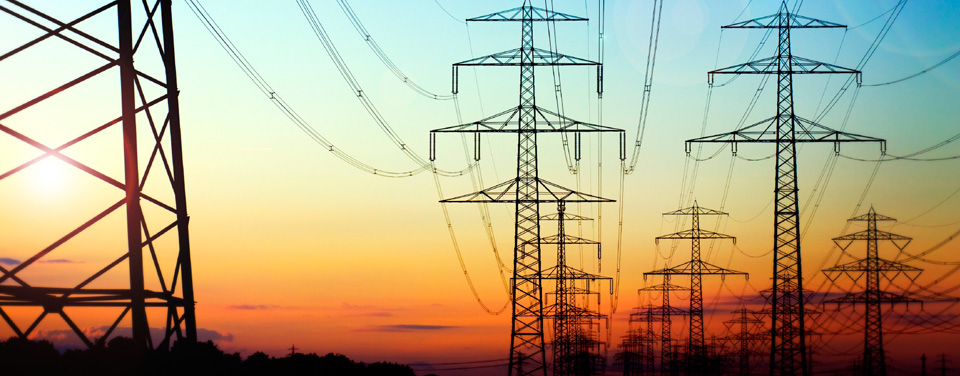

## Objetivos de aprendizaje

Al finalizar este laboratorio podrás:

- construir variables de calendario a partir de un índice temporal;
- separar cronológicamente entrenamiento y prueba;
- ajustar XGBoost con early stopping usando validation, sin consultar test;
- preparar los datos requeridos por Prophet y generar un pronóstico;
- comparar ambos métodos con una métrica de error y gráficos temporales.

## Problema y dataset

La unidad de análisis es una observación horaria de consumo eléctrico de Rumania. La variable objetivo es `Consumption`; el laboratorio usa la fecha y hora para derivar variables de calendario. El CSV también contiene variables de producción por tecnología, que se excluyen en este ejercicio univariado.

El archivo se conserva localmente en `data/external/electricity_consumption_and_production.csv`. La notebook original cita un análisis de Kaggle como contexto, pero la fuente primaria y licencia del CSV están pendientes de verificación.

## Pregunta analítica

¿Qué patrones temporales puede aprender un regresor XGBoost y cómo se compara su pronóstico con Prophet sobre el último año disponible? Una pauta estacional visible no garantiza por sí sola que el patrón se mantenga en el futuro.


## Configuración del entorno

El laboratorio requiere pandas, Matplotlib, XGBoost y Prophet, además del paquete `ml_course` de este repositorio. Ejecuta las celdas en orden y utiliza el entorno instalado desde `machine_learning/requirements.txt`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from prophet import Prophet

## Carga y comprensión de los datos

Se carga la copia local del CSV y se convierte `DateTime` en índice temporal. La ruta se resuelve desde el paquete del proyecto, por lo que no depende de la carpeta desde la que se inició Jupyter.

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('expand_frame_repr', False)

from ml_course.data import get_data_path

df = pd.read_csv(
    get_data_path("electricity_consumption_and_production.csv", category="external")
)

# set the DateTime as the index
df = df.set_index("DateTime")
df.index = pd.to_datetime(df.index)

Se revisa la forma de la tabla y una muestra de filas. Interpreta qué representa una fila y comprueba que `DateTime` y `Consumption` estén disponibles antes de continuar.

In [4]:
print(f"our shape is {df.shape}")
print()
df.head()

our shape is (36772, 9)



,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


Para comparar los modelos en un escenario univariado, se conservan `Consumption` y la marca temporal. Las variables de generación se excluyen porque este notebook no especifica pronósticos futuros para ellas.

In [5]:
df.drop(["Production", "Nuclear", "Wind", "Hydroelectric", "Oil and Gas", "Coal", "Solar", "Biomass"], axis=1, inplace=True)

## Análisis exploratorio temporal

Primero visualiza toda la serie para buscar tendencia, cambios de nivel y variabilidad; el gráfico semanal permite observar el ciclo intradiario. Describe lo que muestran los datos sin asumir que una pauta observada garantiza precisión futura.

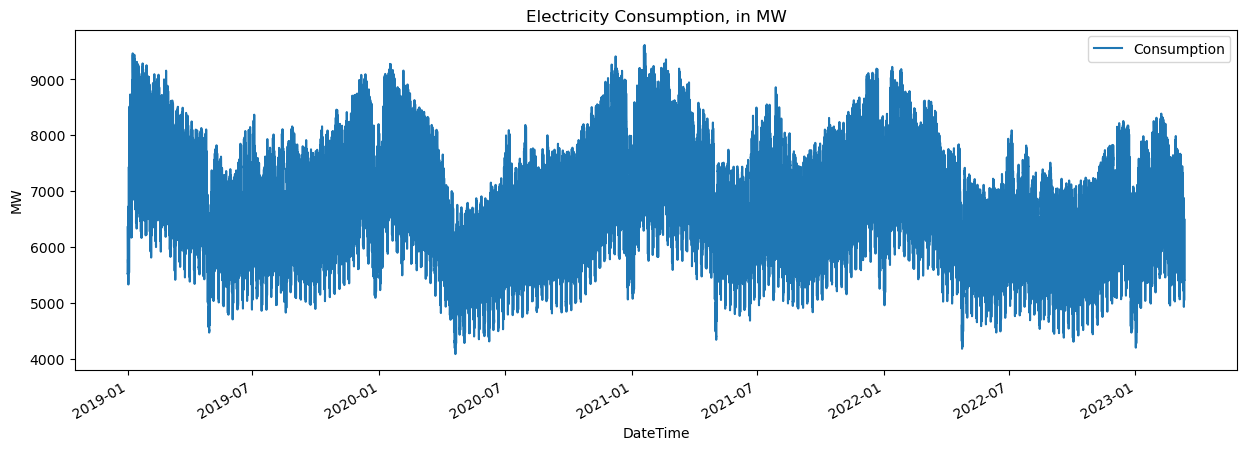

In [6]:
df[["Consumption"]].plot(style="-", figsize=(15, 5), title="Electricity Consumption, in MW")
plt.ylabel('MW')
plt.show()

### Interpretación

Compara los ciclos de distintos días y señala cuáles parecen repetirse. Considera también cambios de nivel y variaciones que no se explican únicamente por la hora del día.

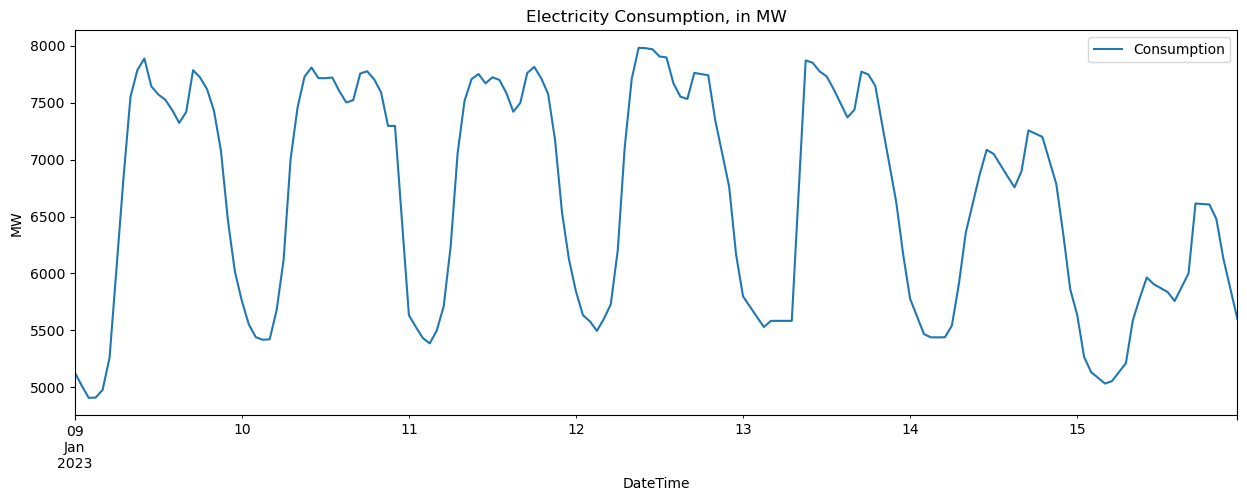

In [7]:
df["2023-01-09 00:00:00" : "2023-01-15 23:59:59"][["Consumption"]].plot(style="-", figsize=(15, 5), title="Electricity Consumption, in MW")
plt.ylabel('MW')
plt.show()

## Estructura temporal y estacionalidad

La visualización semanal ayuda a formular la hipótesis de estacionalidad diaria. La serie puede contener más de un patrón; estos gráficos iniciales no sustituyen el análisis de residuos ni el backtesting.

La imagen resume patrones habituales de una serie temporal, como tendencia y estacionalidad. Úsala como guía para describir la serie observada, no como evidencia suficiente de que será pronosticable.
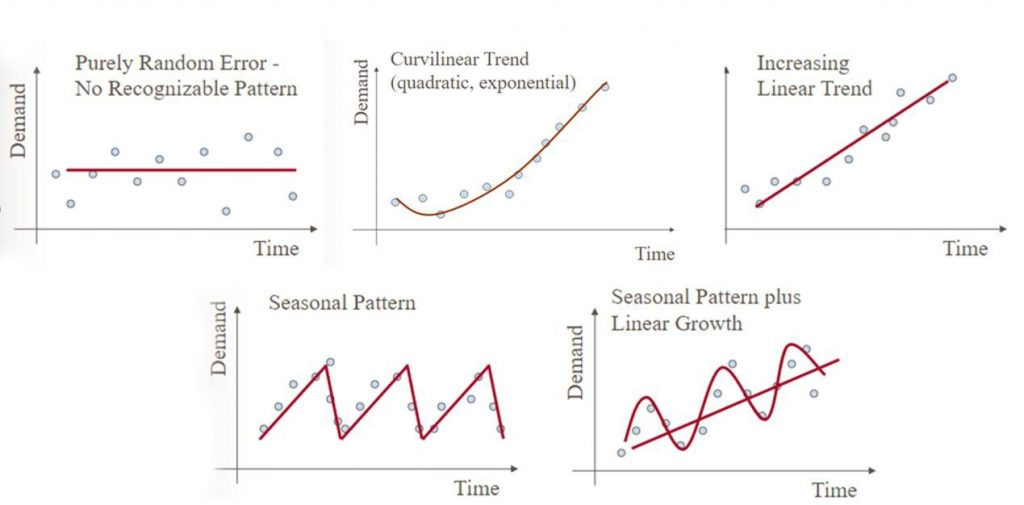

## Preparación y partición temporal

Se derivan variables de calendario (`hour`, `day_of_week`, `quarter`, `month`, `year` y `day_of_year`). El último año se reserva como test; dentro del periodo previo, XGBoost separa el tramo final para early stopping. Prophet se ajusta con el periodo de entrenamiento y se evalúa en el mismo test.

In [8]:
# method for adding time features by the time index
def createTimeFeatures(df):
    df["hour"] = df.index.hour
    df["day_of_week"] = df.index.day_of_week
    df["quarter"] = df.index.quarter
    df["month"] = df.index.month
    df["year"] = df.index.year
    df["day_of_year"] = df.index.dayofyear


# apply the method to the existing dataframe
createTimeFeatures(df)

df.head()

,Consumption,hour,day_of_week,quarter,month,year,day_of_year
DateTime,,,,,,,
2019-01-01 00:00:00,6352,0,1,1,1,2019,1
2019-01-01 01:00:00,6116,1,1,1,1,2019,1
2019-01-01 02:00:00,5873,2,1,1,1,2019,1
2019-01-01 03:00:00,5682,3,1,1,1,2019,1
2019-01-01 04:00:00,5557,4,1,1,1,2019,1


Las variables de calendario se calculan desde `DateTime`. Interpreta `hour` y `day_of_week` como categorías cíclicas: tratarlas como números ordinales en XGBoost impone un orden y distancia que no representa completamente la periodicidad.

cutOffDate 2022-03-13 01:00:00
train size: 28013 and test 8759


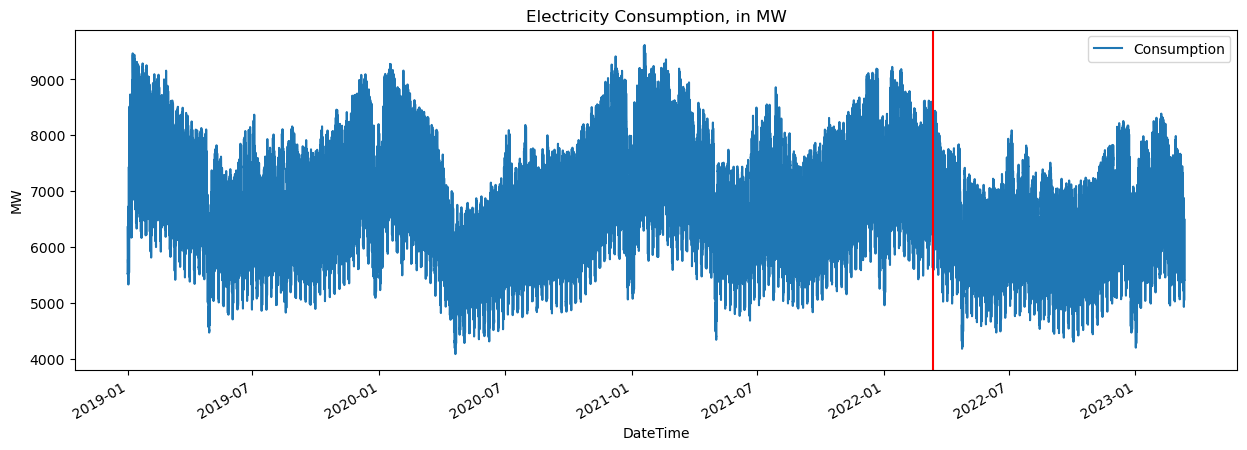

In [9]:
cutOffDate = df.index[-365 * 24]
print(f"cutOffDate {cutOffDate}")

train = df.loc[df.index <= cutOffDate]
test = df.loc[df.index > cutOffDate]

print(f"train size: {len(train)} and test {len(test)}")

df[["Consumption"]].plot(style="-", figsize=(15, 5), title="Electricity Consumption, in MW")
plt.ylabel('MW')
plt.axvline(x=cutOffDate, color='r')
plt.show()

La partición conserva el orden temporal: los datos más recientes quedan en test. No uses observaciones de test para seleccionar hiperparámetros ni para early stopping.

## Métrica porcentual de error

La función calcula Mean Absolute Percentage Error (MAPE), que expresa el error absoluto medio como porcentaje del valor real. MAPE no está definido para observaciones reales iguales a cero; la función debe excluirlas o reportar esa limitación explícitamente.

In [ ]:
def meanAbsolutErrorAaPercentage(real, predicted):
    real = np.asarray(real, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    nonzero = real != 0

    if not np.any(nonzero):
        return float("nan")

    return np.mean(np.abs((real[nonzero] - predicted[nonzero]) / real[nonzero])) * 100

## Modelo 1: regresión con XGBoost

XGBoost recibe las variables de calendario y predice `Consumption`. El tramo final de entrenamiento se usa como validation para early stopping; el último año permanece reservado para medir el rendimiento final.

In [ ]:
%%time

# Define features and target for the chronological forecasting task.
FEATURES = ["hour", "day_of_week", "quarter", "month", "year", "day_of_year"]
TARGET = "Consumption"

validation_size = max(1, int(len(train) * 0.15))
model_train = train.iloc[:-validation_size]
validation = train.iloc[-validation_size:]

X_model_train = model_train[FEATURES]
y_model_train = model_train[TARGET]
X_validation = validation[FEATURES]
y_validation = validation[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

# Early stopping selects the number of boosting rounds using validation only.
regressor = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    learning_rate=0.01,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
)
regressor.fit(
    X_model_train,
    y_model_train,
    eval_set=[(X_validation, y_validation)],
    verbose=False,
)

validation_prediction = regressor.predict(X_validation)
regressorOutput = regressor.predict(X_test)

prediction = pd.DataFrame(data=regressorOutput, index=X_test.index, columns=["prediction"])
df = df.merge(prediction, how="left", left_index=True, right_index=True)

print(f"Validation MAPE: {meanAbsolutErrorAaPercentage(y_validation, validation_prediction):.2f}%")
df.tail()

[21:52:50] WARNING: ../src/learner.cc:627: 
Parameters: { "early_stoppin_rounds" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[0]	validation_0-rmse:6852.08195	validation_1-rmse:6269.68302
[100]	validation_0-rmse:2541.38686	validation_1-rmse:1963.33421
[200]	validation_0-rmse:985.37916	validation_1-rmse:500.99195
[300]	validation_0-rmse:457.49765	validation_1-rmse:460.05065
[400]	validation_0-rmse:297.47595	validation_1-rmse:606.25707
[500]	validation_0-rmse:248.45966	validation_1-rmse:666.94839
[600]	validation_0-rmse:227.25398	validation_1-rmse:697.69799
[700]	validation_0-rmse:213.72281	validation_1-rmse:711.94840
[800]	validation_0-rmse:203.99982	validation_1-rmse:716.76895
[900]	validation_0-rmse:196.55264	validation_1-rmse:715.94953
[999]	v

,Consumption,hour,day_of_week,quarter,month,year,day_of_year,prediction
DateTime,,,,,,,,
2023-03-12 19:00:00,6500,19,6,1,3,2023,71,7279.210449
2023-03-12 20:00:00,6471,20,6,1,3,2023,71,7315.285156
2023-03-12 21:00:00,6194,21,6,1,3,2023,71,7093.613281
2023-03-12 22:00:00,5708,22,6,1,3,2023,71,6637.982422
2023-03-12 23:00:00,5409,23,6,1,3,2023,71,6326.312012


## Evaluación en test

Calcula el error porcentual sobre el periodo reservado. Interpreta el resultado en relación con el nivel de consumo y compáralo después con Prophet y con el baseline estacional.

In [12]:
# select the part of the data frame that is our test part
testDf = df.loc[df.index > cutOffDate]

yReal = testDf["Consumption"]
yPredicted = testDf["prediction"]

print(f"percentage error: {meanAbsolutErrorAaPercentage(yReal, yPredicted):.4f}")

percentage error: 10.1803


### Interpretación

No se fija aquí un valor de error porque depende de la ejecución, las versiones y el corte temporal. Usa la métrica calculada arriba; una cifra menor no basta para elegir el modelo si cambian la estabilidad o el comportamiento por horizonte.

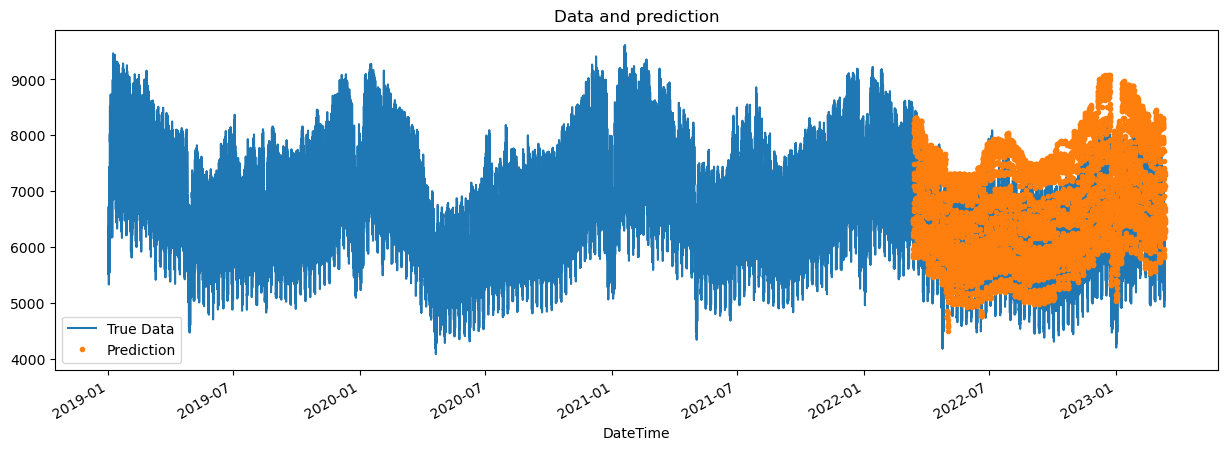

In [13]:
ax = df[[TARGET]].plot(figsize=(15,5))
df["prediction"].plot(ax=ax, style=".")
ax.legend(["True Data", "Prediction"])
ax.set_title("Data and prediction")
plt.show()

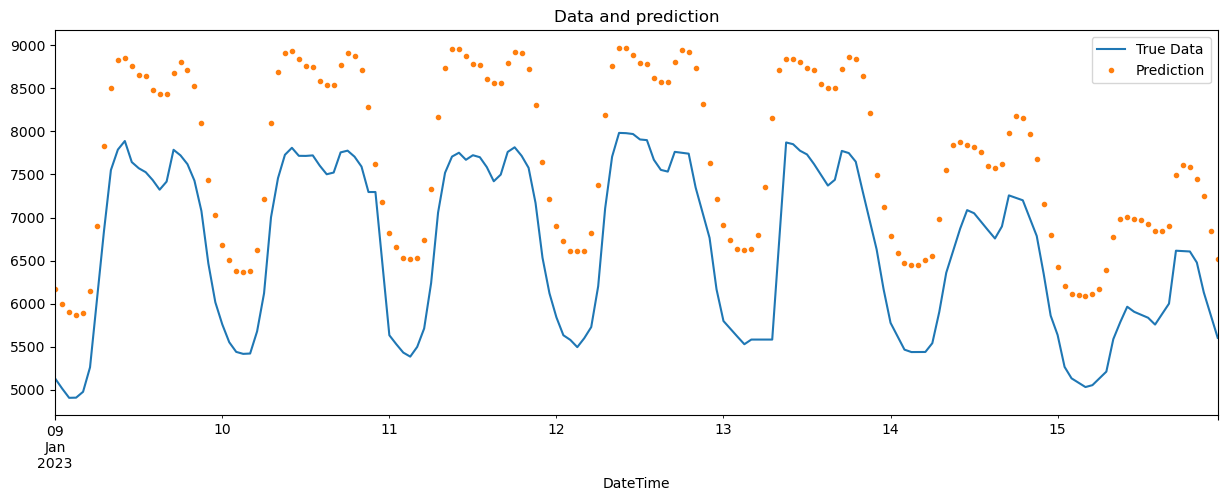

In [14]:
ax = df["2023-01-09 00:00:00" : "2023-01-15 23:59:59"][[TARGET]].plot(figsize=(15,5))
df["2023-01-09 00:00:00" : "2023-01-15 23:59:59"]["prediction"].plot(ax=ax, style=".")
ax.legend(["True Data", "Prediction"])
ax.set_title("Data and prediction")
plt.show()

### Interpretación de las predicciones

Observa si el modelo sigue nivel, tendencia y ciclos, y en qué periodos se desvía. Distingue coincidencia visual de precisión: contrasta el gráfico con los errores sobre el mismo test.

## Modelo 2: Prophet

Prophet representa la serie mediante componentes aditivos de tendencia y estacionalidad. La interfaz espera la fecha en `ds` y la observación objetivo en `y`; el ajuste usa solo `train` y el pronóstico cubre las fechas de `test`.

In [15]:
prophetTrain = train.reset_index()
prophetTrain.drop(FEATURES, axis=1, inplace=True)
prophetTrain.rename(columns={"DateTime": "ds", "Consumption": "y"}, inplace=True)

prophetTrain.tail()

,ds,y
28008,2022-03-12 21:00:00,7458
28009,2022-03-12 22:00:00,6912
28010,2022-03-12 23:00:00,6377
28011,2022-03-13 00:00:00,6119
28012,2022-03-13 01:00:00,5864


In [16]:
prophetTest = test.reset_index()
prophetTest.drop(FEATURES, axis=1, inplace=True)
prophetTest.rename(columns={"DateTime": "ds", "Consumption": "y"}, inplace=True)

prophetTest.tail()

,ds,y
8754,2023-03-12 19:00:00,6500
8755,2023-03-12 20:00:00,6471
8756,2023-03-12 21:00:00,6194
8757,2023-03-12 22:00:00,5708
8758,2023-03-12 23:00:00,5409


Se convierten las particiones al esquema de Prophet: `ds` contiene las fechas y `y` el consumo observado. Las fechas de test se utilizan para solicitar predicciones, no para ajustar el modelo.

In [17]:
%%time

prophetModel = Prophet()
prophetModel.fit(prophetTrain)

prophetPrediction = prophetModel.predict(prophetTest)

yRealProphet = test["Consumption"]
yPredictedProphet = prophetPrediction["yhat"]

print(f"prophet percentage error: {meanAbsolutErrorAaPercentage(yRealProphet, yPredictedProphet):.4f}")

21:53:11 - cmdstanpy - INFO - Chain [1] start processing
21:53:45 - cmdstanpy - INFO - Chain [1] done processing


prophet percentage error: 5.5591
CPU times: user 6.02 s, sys: 1.02 s, total: 7.04 s
Wall time: 40.9 s


### Interpretación

Calcula y compara el MAPE de Prophet en el mismo test que XGBoost. Describe en qué tramos temporales mejora o empeora cada pronóstico; no infieras superioridad a partir de un resultado previo guardado.

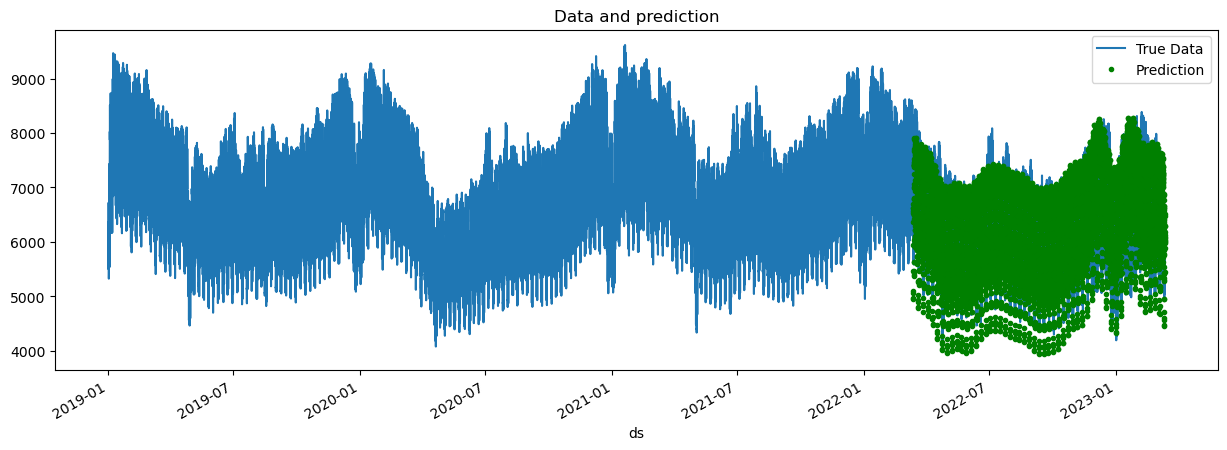

In [18]:
# in order to be optimaly plot the data we set it's ds (our initial DateTime) as the index
prophetPrediction = prophetPrediction.set_index("ds")

ax = df[[TARGET]].plot(figsize=(15,5))
prophetPrediction["yhat"].plot(ax=ax, style=".", color="g")
ax.legend(["True Data", "Prediction"])
ax.set_title("Data and prediction")
plt.show()

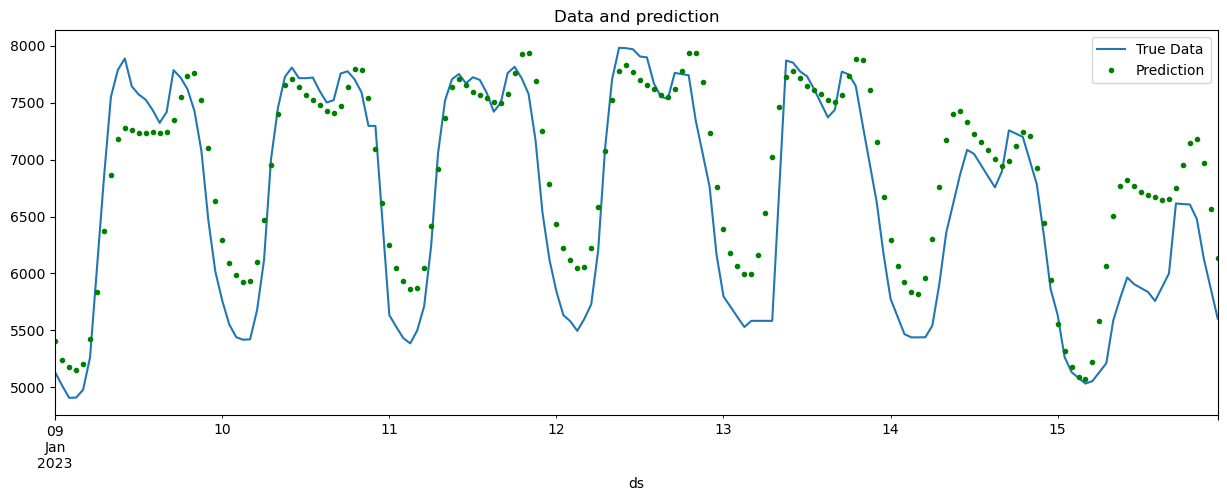

In [19]:
ax = df["2023-01-09 00:00:00" : "2023-01-15 23:59:59"][[TARGET]].plot(figsize=(15,5))
prophetPrediction["2023-01-09 00:00:00" : "2023-01-15 23:59:59"]["yhat"].plot(ax=ax, style=".", color="g")
ax.legend(["True Data", "Prediction"])
ax.set_title("Data and prediction")
plt.show()

### Interpretación de los gráficos

Compara los pronósticos con la serie observada en el periodo completo y en la semana mostrada. Identifica desfases, picos no capturados y diferencias entre la forma global y el comportamiento local.

## Comparación cuantitativa

Los tres métodos se evalúan sobre las mismas fechas de test: un baseline estacional que repite el último ciclo diario disponible, XGBoost y Prophet. El baseline usa únicamente información disponible antes del origen del pronóstico. Compara MAE, RMSE y MAPE; no elijas un modelo usando una sola métrica.

In [ ]:
# Baseline estacional de origen fijo: repite el ultimo ciclo diario observado.
seasonal_naive_forecast = pd.Series(
    np.resize(train[TARGET].iloc[-24:].to_numpy(), len(test)),
    index=test.index,
)
forecast_by_model = {
    "Naive estacional (24 h)": seasonal_naive_forecast,
    "XGBoost": pd.Series(regressorOutput, index=X_test.index),
    "Prophet": pd.Series(yPredictedProphet.to_numpy(), index=test.index),
}

comparison_rows = []
for model_name, forecast in forecast_by_model.items():
    comparison = pd.concat(
        [test[TARGET].rename("actual"), forecast.rename("pronostico")],
        axis=1,
    ).dropna()
    errors = comparison["actual"] - comparison["pronostico"]
    comparison_rows.append({
        "modelo": model_name,
        "MAE": np.mean(np.abs(errors)),
        "RMSE": np.sqrt(np.mean(errors ** 2)),
        "MAPE_%": meanAbsolutErrorAaPercentage(
            comparison["actual"], comparison["pronostico"]
        ),
    })

model_comparison = pd.DataFrame(comparison_rows).sort_values("RMSE")
display(model_comparison.round(3))

## Conclusiones

Resume la estructura temporal observada, las decisiones de partición y el desempeño de XGBoost, Prophet y el baseline cuando se calcule la comparación. Explica las limitaciones del horizonte, de las variables de calendario y de la procedencia del dataset. No declares un ganador sin contrastar métricas y gráficos.

## Ejercicios propuestos

1. Compara el pronóstico con un baseline estacional que repita el último ciclo diario disponible.
2. Cambia la duración del periodo reservado y analiza cómo varía el error sin barajar fechas.
3. Examina por separado los errores por hora del día y por día de la semana.
4. Discute qué información adicional se necesitaría para usar variables de producción como regresores futuros.

## Referencias

- Taylor, S. J. y Letham, B. (2018). Forecasting at scale. *The American Statistician*, 72(1), 37-45. https://doi.org/10.1080/00031305.2017.1380080
- [Documentación oficial de Prophet](https://facebook.github.io/prophet/)
- [Contexto de visualización citado por el notebook original](https://www.kaggle.com/code/stefancomanita/electricity-consumption-production-visualization). La procedencia primaria del CSV queda pendiente de verificar.